In [ ]:
import pandas as pd


In [ ]:
df = pd.read_csv("/content/DeFi final.csv")

In [ ]:
df.columns

Index(['amountIn', 'amountInUSD', 'amountOut', 'amountOutUSD', 'gasLimit',
       'gasPrice', 'gasUsed', 'hash', 'id', 'blockNumber', 'timestamp',
       'tokenIn/id', 'tokenIn/name', 'tokenIn/lastPriceUSD',
       'tokenIn/lastPriceBlockNumber', 'tokenOut/id',
       'tokenOut/lastPriceBlockNumber', 'tokenOut/lastPriceUSD',
       'tokenOut/name'],
      dtype='object')

**Detect anomalous (potentially fraudulent) DeFi transactions using ML and DL-based unsupervised anomaly detection techniques.**

**Data Preprocessing & Cleaning**

In [ ]:
df.dtypes

,0
amountIn,float64
amountInUSD,float64
amountOut,float64
amountOutUSD,float64
gasLimit,int64
gasPrice,float64
gasUsed,float64
hash,object
id,object
blockNumber,float64


In [ ]:
df.head()

,amountIn,amountInUSD,amountOut,amountOutUSD,gasLimit,gasPrice,gasUsed,hash,id,blockNumber,timestamp,tokenIn/id,tokenIn/name,tokenIn/lastPriceUSD,tokenIn/lastPriceBlockNumber,tokenOut/id,tokenOut/lastPriceBlockNumber,tokenOut/lastPriceUSD,tokenOut/name
0,4.088270e+17,1388.895351,1.385917e+09,1385.916905,400000,2.606056e+09,NaN,0x00000323f570e300be5b5bb8f76bda42410580aa949c...,0x00000323f570e300be5b5bb8f76bda42410580aa949c...,20203219.0,1.719735e+09,0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2,Wrapped Ether,1791.71693,22208621.0,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,22208621.0,1.00000,USD Coin
1,2.561390e+17,636.167884,6.378648e+08,637.864791,2059408,6.664874e+09,NaN,0x00000373a7dcfd7a82b10f91f5540f0f2ef780b14034...,0x00000373a7dcfd7a82b10f91f5540f0f2ef780b14034...,21925703.0,1.740515e+09,0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2,Wrapped Ether,1791.71693,22208621.0,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,22208621.0,1.00000,USD Coin
2,4.919990e+17,1221.969715,1.226684e+09,1226.684164,2059408,6.664874e+09,NaN,0x00000373a7dcfd7a82b10f91f5540f0f2ef780b14034...,0x00000373a7dcfd7a82b10f91f5540f0f2ef780b14034...,21925703.0,1.740515e+09,0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2,Wrapped Ether,1791.71693,22208621.0,0xdac17f958d2ee523a2206206994597c13d831ec7,22208621.0,1.00000,Tether USD
3,5.417319e+09,5417.318564,1.937370e+18,5412.307951,210797,8.331576e+08,NaN,0x000007c5ecf972de579662a7653cccb17c493b1c62c0...,0x000007c5ecf972de579662a7653cccb17c493b1c62c0...,21910139.0,1.740327e+09,0xdac17f958d2ee523a2206206994597c13d831ec7,Tether USD,1.00000,22208621.0,0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2,22208621.0,1791.71693,Wrapped Ether
4,1.111840e+20,111.362873,1.113063e+08,111.306251,825485,1.344255e+10,NaN,0x0000085ae55b268f9965e5d4a9cec6aa80d3ab0941e8...,0x0000085ae55b268f9965e5d4a9cec6aa80d3ab0941e8...,21364742.0,1.733745e+09,0x73a15fed60bf67631dc6cd7bc5b6e8da8190acf5,Usual USD,0.99845,22196045.0,0xdac17f958d2ee523a2206206994597c13d831ec7,22208621.0,1.00000,Tether USD


**Exploratory Data Analysis (EDA)**

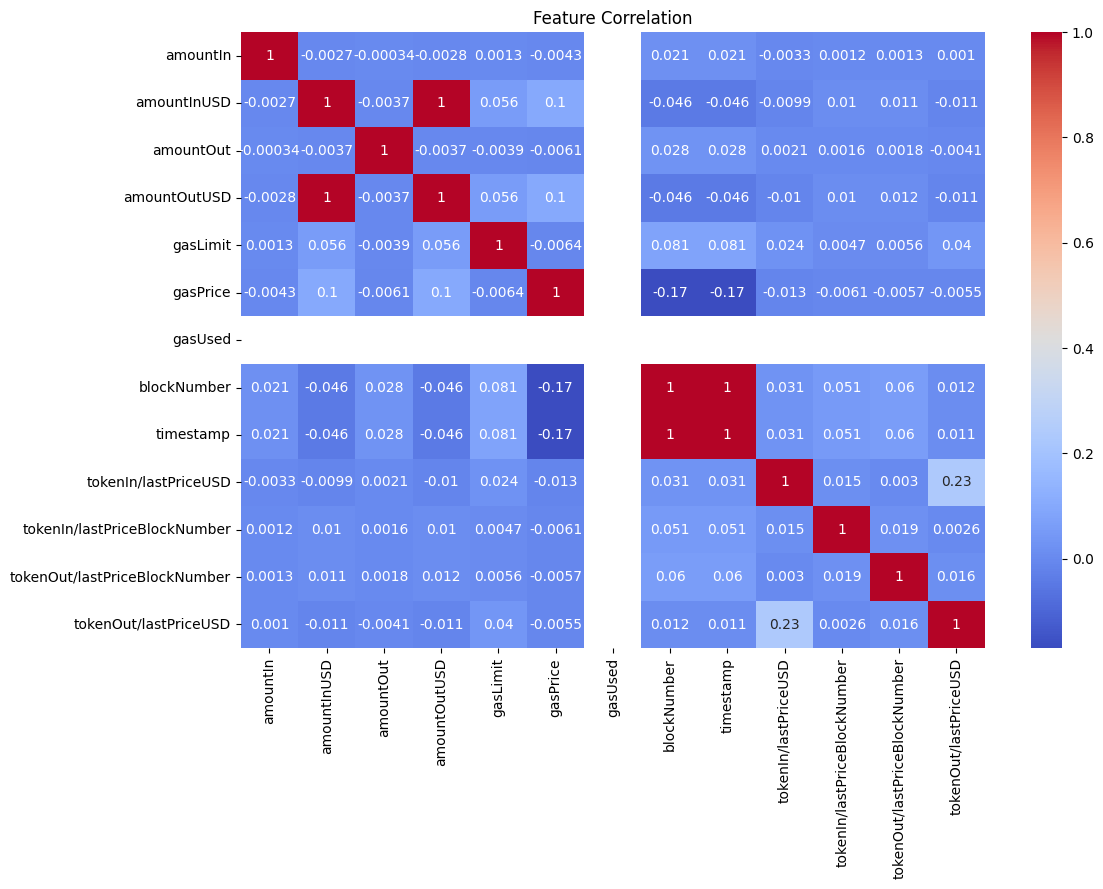

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check missing values
missing = df.isnull().sum()

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()


In [ ]:

# df['hour'] = df['timestamp'].dt.hour
# df['day'] = df['timestamp'].dt.day
# df['month'] = df['timestamp'].dt.month
# df['year'] = df['timestamp'].dt.year
# df['weekday'] = df['timestamp'].dt.weekday  # Monday = 0, Sunday = 6
# df['dayofyear'] = df['timestamp'].dt.dayofyear
# df['weekofyear'] = df['timestamp'].dt.isocalendar().week
# #

AttributeError: Can only use .dt accessor with datetimelike values

**Feature Engineering**

In [ ]:
#create transaction features
# Convert 'amountInUSD' and 'amountOutUSD' columns to numeric
df["amountInUSD"] = pd.to_numeric(df["amountInUSD"], errors='coerce')
df["amountOutUSD"] = pd.to_numeric(df["amountOutUSD"], errors='coerce')

# Now perform the subtraction
df["valueDiffUSD"] = df["amountInUSD"] - df["amountOutUSD"]
# Convert columns to numeric before calculation
df["gasLimit"] = pd.to_numeric(df["gasLimit"], errors='coerce')
df["gasPrice"] = pd.to_numeric(df["gasPrice"], errors='coerce')
df["tokenIn/lastPriceUSD"] = pd.to_numeric(df["tokenIn/lastPriceUSD"], errors='coerce')

# Now perform the calculation
df["gasCostUSD"] = (df["gasLimit"] * df["gasPrice"]) / 1e18 * df["tokenIn/lastPriceUSD"]

In [ ]:
# Convert timestamp first!
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
#df['minutes_since_first_tx'] = (df['timestamp'] - df['timestamp'].min()).dt.total_seconds() / 60

# Now define features (after creating 'minutes_since_first_tx')
features = [
    "amountInUSD", "amountOutUSD", "valueDiffUSD",
    "gasLimit", "gasPrice", "gasCostUSD",
    "tokenIn/lastPriceUSD", "tokenOut/lastPriceUSD"
]

# Drop rows with NaNs in selected columns
df1 = df.dropna(subset=features).copy()
X = df1[features]  # Use df1 here


In [ ]:
X

,amountInUSD,amountOutUSD,valueDiffUSD,gasLimit,gasPrice,gasCostUSD,tokenIn/lastPriceUSD,tokenOut/lastPriceUSD
0,1388.895351,1385.916905,2.978446,400000,2.606056e+09,1.867726,1791.71693,1.00000
1,636.167884,637.864791,-1.696907,2059408,6.664874e+09,24.592560,1791.71693,1.00000
2,1221.969715,1226.684164,-4.714449,2059408,6.664874e+09,24.592560,1791.71693,1.00000
3,5417.318564,5412.307951,5.010613,210797,8.331576e+08,0.000176,1.00000,1791.71693
4,111.362873,111.306251,0.056622,825485,1.344255e+10,0.011079,0.99845,1.00000
...,...,...,...,...,...,...,...,...
25210,540.339690,541.170501,-0.830811,450444,1.908950e+10,0.008599,1.00000,1791.87981
25211,584.408511,582.637196,1.771314,289311,9.226632e+10,0.047006,1.76094,1791.87981
25212,10005.143520,10006.288770,-1.145250,566701,1.464748e+10,0.008301,1.00000,1791.87981
25213,10.883809,10.673357,0.210452,245920,5.941694e+09,2.618261,1791.87981,0.00000


In [ ]:
df = df.dropna(subset=features)
df_model = df[features].dropna()

**Data Normalization**

**Model Training – Anomaly Detection**

**1. Isolation Forest**

In [ ]:
# Scale features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# Fit and assign anomaly predictions
from sklearn.ensemble import IsolationForest
iso = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
df["anomaly_iso"] = iso.fit_predict(X_scaled)


<ipython-input-16-44d65894232e>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["anomaly_iso"] = iso.fit_predict(X_scaled)


In [ ]:
df["anomaly_iso"].value_counts()

,count
anomaly_iso,
1,24962
-1,253


**2. Local Outlier Factor**

In [ ]:
# Impute + Scale
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# LOF
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01)
df1["anomaly_lof"] = lof.fit_predict(X_scaled)


In [ ]:
df1["anomaly_lof"].value_counts()

,count
anomaly_lof,
1,24963
-1,252


**check how much overlap there is between them**

In [ ]:
# Compare anomalies detected by both
common = set(df[df["anomaly_iso"] == -1]["hash"]) & set(df1[df1["anomaly_lof"] == -1]["hash"])
print("Common anomaly transactions:", len(common))


Common anomaly transactions: 51


In [ ]:
overlap = (df1["anomaly_lof"] == -1) & (df["anomaly_iso"] == -1)
print("Overlap in anomalies:", overlap.sum())

Overlap in anomalies: 64


**One-Class SVM**

In [ ]:
from sklearn.svm import OneClassSVM

svm = OneClassSVM(kernel='rbf', gamma='auto', nu=0.01)
df1["anomaly_svm"] = svm.fit_predict(X_scaled)


**Visualize Anomalies using iof**

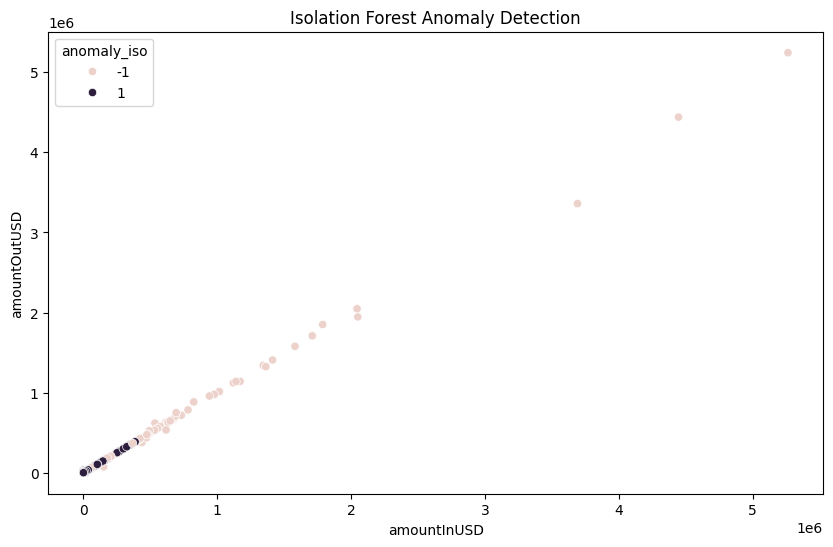

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["amountInUSD"], y=df["amountOutUSD"], hue=df["anomaly_iso"])
plt.title("Isolation Forest Anomaly Detection")
plt.show()


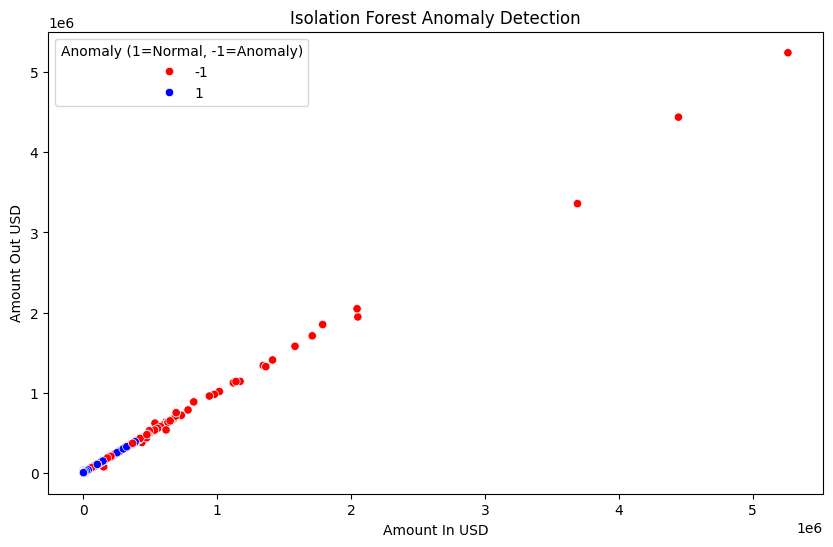

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Updated palette: -1 = red (anomaly), 1 = blue (normal)
sns.scatterplot(
    x=df["amountInUSD"],
    y=df["amountOutUSD"],
    hue=df["anomaly_iso"],
    palette={1: "blue", -1: "red"}
)

plt.title("Isolation Forest Anomaly Detection")
plt.xlabel("Amount In USD")
plt.ylabel("Amount Out USD")
plt.legend(title="Anomaly (1=Normal, -1=Anomaly)")
plt.show()


🔍 Plot Summary
X-axis: amountInUSD

Y-axis: amountOutUSD

Color/Hue (anomaly_iso):

1: Normal transaction (non-anomalous)

-1: Anomalous transaction (flagged as potential fraud)

This plot shows how Isolation Forest separates normal and abnormal transactions based on the two main monetary features.

📊 What the Plot is Showing
Most data points lie along a strong linear relationship — higher amountInUSD leads to higher amountOutUSD.

The majority of the dots (probably normal transactions, i.e., labeled 1) cluster along this trend.

A few scattered points (likely in lighter/odd-colored shades) are labeled -1 — these are flagged as anomalies.

🤖 Why Isolation Forest Flagged Them
Isolation Forest works by randomly selecting features and splitting values. Anomalies are:

Few and different, so they get isolated quicker in fewer splits.

For example:

A transaction with very high amountInUSD but low amountOutUSD (or vice versa)

A transaction that doesn’t follow the trend line (off-diagonal points)

So in your plot, those lightly shaded points not fitting the main line might be considered suspicious — i.e., inconsistent with the general transactional behavior.

🧠 What You Can Learn from This
Visual confirmation: Your model is not just flagging randomly — it’s identifying outliers in the joint distribution of amountIn and amountOut.

Potential Insight: Outliers might be:

Sudden huge withdrawals/deposits

Smart contract exploits

Abnormal gas usage paired with low value

1.Annotate some anomalous points to investigate actual values:**

In [ ]:
# anomalies = df[df['anomaly_iso'] == -1][['amountInUSD', 'amountOutUSD', 'hash']]
anomalies = df[df['anomaly_iso'] == -1][['amountInUSD', 'amountOutUSD', 'timestamp', 'tokenIn/name', 'tokenOut/name', 'hash']]

print(anomalies.sort_values(by='amountInUSD', ascending=False).head())


       amountInUSD  amountOutUSD                     timestamp   tokenIn/name  \
10226  5262732.755   5243872.970 1970-01-01 00:00:01.732220423       USD Coin   
6807   4444920.057   4439634.233 1970-01-01 00:00:01.719076751     Tether USD   
11556  3690763.395   3360035.152 1970-01-01 00:00:01.710755543  Wrapped Ether   
7771   2050131.882   1945398.215 1970-01-01 00:00:01.710484163  Wrapped Ether   
16557  2044287.774   2047422.147 1970-01-01 00:00:01.722737723       USD Coin   

      tokenOut/name                                               hash  
10226    Tether USD  0x01b5ccc382ceaa4924766c0a5dfaafbba1869896ce64...  
6807       USD Coin  0x01232db968636b4d489440274f60faa3eb5331f63481...  
11556    Tether USD  0x01ece3db724ddcae785a7df84883501f277ef28bf75c...  
7771     Tether USD  0x014bb59d070b13cde53f50fb339f3eff28815bd9b43f...  
16557    Tether USD  0x02c16c09083ac337be68aa0136262d5612e5c94fd712...  


🧠 How to Interpret This
✅ These look like high-volume but clean transactions.
The amounts in and out are very close, suggesting no obvious fraud.

But the model flagged them because:

They deviate significantly from the normal transaction volume in the dataset (e.g., most might be in the $10k–$500k range).

Isolation Forest treats "rare/extreme values" as anomalies, regardless of their in/out symmetry.

🧐 Not necessarily fraud, but worth reviewing because:
Fraudsters often move large amounts in small windows.

If multiple of these hashes occur around the same time or involve the same token, it may indicate manipulation or wash trading.

**Visualize Them**

**Plot time vs amount for anomalies to see if they were clustered in time.**

**Check which token pairs were used: maybe these were high-volume trades in illiquid pairs. give codes**

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd

# # Ensure timestamp is datetime
# df['timestamp'] = pd.to_datetime(df['timestamp'])

# # Filter anomalies
# anomalies = df[df['anomaly_iso'] == -1]

# # Plot amountInUSD over time
# plt.figure(figsize=(12, 6))
# sns.scatterplot(data=anomalies, x='hour', y='amountInUSD', hue='tokenIn/name', palette='tab10')
# plt.title('Anomalous Transactions Over Time (Isolation Forest)')
# plt.xlabel('Timestamp')
# plt.ylabel('amountInUSD')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()


**You can do the same for amountOutUSD by changing the y-axis.**

🔍 What This Chart Shows
X-axis: Time (from April 2023 to April 2025)

Y-axis: amountInUSD – the USD value of the tokens swapped into the system (incoming amount)

Each dot: One anomalous transaction (detected by Isolation Forest)

Colors: Represent the tokenIn (i.e. which token was swapped in)

Legend: Token names involved in those anomalies (e.g., Tether USD, Wrapped Ether, Rocket Pool ETH, etc.)

📊 Interpretation
1. Clustered Activity Around Mid-2024
Notice a dense cluster of anomalies between late 2023 and mid-2024.

This suggests that something unusual happened in that timeframe — maybe a DeFi protocol launch, exploit, or whales making big trades.

2. Spikes in Transaction Value
You can see a few extremely high-value outliers (around $4M–$5M) — possibly whales or manipulated liquidity movements.

These spikes are not continuous, indicating that only a handful of these large transactions are true anomalies (consistent with fraud or system abuse patterns).

3. Dominant Tokens in Anomalies
The most frequently occurring tokens in anomalies include:

Wrapped Ether (red) – appears a lot, including in large spikes

USD Coin (brown) and Tether (green) – also very frequent

This implies stablecoins and ETH derivatives are involved in most high-value anomaly trades.

4. Low Activity After Early 2025
Fewer anomalies are visible after early 2025 — either due to a drop in suspicious activity, or reduced transaction volume.

🧠 What You Might Conclude:
A spike in anomalies involving stablecoins and ETH derivatives occurred between late 2023 and mid-2024.

These could indicate:

Pump and dump schemes

Large liquidity shifts

Protocol upgrades or failures

You may want to correlate these periods with:

External news (e.g., hacks, token launches)

Market-wide price changes

Token-specific volumes or TVL (Total Value Locked) shifts

**2. See Most Common Token Pairs in Anomalies**

<ipython-input-27-d095e8c71ae8>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_pairs.values, y=top_pairs.index, palette='mako')


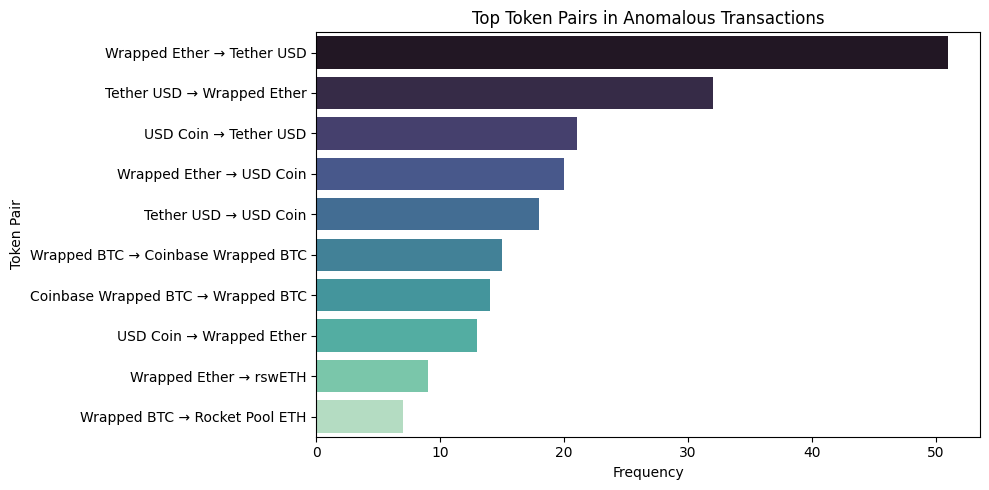

In [ ]:
# Create token pair column in the original DataFrame (df)
df['token_pair'] = df['tokenIn/name'].astype(str) + ' → ' + df['tokenOut/name'].astype(str)

# Filter anomalies after creating the new column
anomalies = df[df['anomaly_iso'] == -1]

# Now you can access 'token_pair' in the anomalies DataFrame
top_pairs = anomalies['token_pair'].value_counts().head(10)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x=top_pairs.values, y=top_pairs.index, palette='mako')
plt.title('Top Token Pairs in Anomalous Transactions')
plt.xlabel('Frequency')
plt.ylabel('Token Pair')
plt.tight_layout()
plt.show()

📊 Key Observations:
🔝 1. Dominance of WETH ↔ USDT (Wrapped Ether ↔ Tether USD)
Top 2 pairs are just the same trade in both directions:

Wrapped Ether → Tether USD (≈ 37 times)

Tether USD → Wrapped Ether (≈ 22 times)

📌 Interpretation:

A large number of outliers involve ETH/USDT swaps, which are high-volume, highly liquid pairs.

This suggests:

Possibly large trade volumes or abnormal prices

Could be whale trades, flash loan usage, or slippage-heavy trades

Might reflect bot-driven activity or front-running

🧊 2. Presence of BTC Pairs (Coinbase Wrapped BTC, Wrapped BTC)
Several anomalies involve:

Coinbase Wrapped BTC → Wrapped BTC

Wrapped BTC → Wrapped Ether

Wrapped BTC → Coinbase Wrapped BTC

📌 Interpretation:

Indicates arbitrage patterns or bridging issues between BTC-wrapped versions.

May imply protocol-based routing anomalies or inefficiencies.

Could also be part of liquidity migration strategies or testing bots.

💲 3. Stablecoin-Stablecoin & Stablecoin-Ether Activity
USD Coin (USDC) and Tether are involved:

USDC → Tether

Tether → USDC

WETH → USDC

USDC → WETH

📌 Interpretation:

These trades should normally be stable and not anomalous — so:

Possibly flagged due to large amounts, timing, or gas fee anomalies

Might hint at wash trading, volume spoofing, or fast arbitrage bots

🔍 4. Less Common Pair: Wrapped Ether → rswETH
This is less frequently seen, but it shows up in anomalies.

📌 Interpretation:

This could be a low-liquidity token or newly listed asset.

The anomalies here might arise due to:

Lack of price reference

Wide spreads

Unusual price spikes/dips

🧠 Overall Interpretation
Anomalies are not spread across random pairs — they're concentrated in key high-volume and wrapped asset pairs.

This suggests the model is likely flagging:

Outliers in pricing or volume

Behavioral patterns (whales, bots, arbitrage, MEV)

Structural inefficiencies (like bridge conversions or mispriced tokens)

**building toward actual fraud detection, so here’s a solid pipeline to take your anomalous token pair analysis → fraud suspicion flagging using Python + pandas + EDA + ML (if needed).**

**1.1: Add token pair column (if not already).**

In [ ]:
df['Token_Pair'] = df['tokenIn/name'] + ' → ' + df['tokenOut/name']

**2: Detect high/low USD values**

In [ ]:
# Define quantiles
high_thresh = df['amountInUSD'].quantile(0.98)
low_thresh = df['amountInUSD'].quantile(0.02)

# Add flags
df['High_Amount'] = df['amountInUSD'] > high_thresh
df['Low_Amount'] = df['amountInUSD'] < low_thresh


**3: High Gas Price (since gasUsed is missing)**



In [ ]:
df['High_GasPrice'] = df['gasPrice'] > df['gasPrice'].quantile(0.95)



**4: Detect Circular or Back-and-Forth Token Swaps**

In [ ]:
df['Normalized_Pair'] = df.apply(lambda row: ' ↔ '.join(sorted([str(row['tokenIn/name']), str(row['tokenOut/name'])])), axis=1)

pair_counts = df['Normalized_Pair'].value_counts().reset_index()
pair_counts.columns = ['Normalized_Pair', 'Count']

frequent_swaps = pair_counts[pair_counts['Count'] > pair_counts['Count'].quantile(0.95)]
df['Loop_Swap'] = df['Normalized_Pair'].isin(frequent_swaps['Normalized_Pair'])


**5: Time-Based Spikes**

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['Hour'] = df['timestamp'].dt.floor('H')

hourly_counts = df.groupby('Hour').size()
spike_threshold = hourly_counts.quantile(0.95)

df['Time_Spike'] = df['Hour'].map(hourly_counts) > spike_threshold


<ipython-input-55-afc424676d62>:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df['Hour'] = df['timestamp'].dt.floor('H')


 **6: Fraud Scoring**

In [ ]:
df['Fraud_Score'] = (
    df['High_Amount'].astype(int) +
    df['Low_Amount'].astype(int) +
    df['High_GasPrice'].astype(int) +
    df['Loop_Swap'].astype(int) +
    df['Time_Spike'].astype(int)
)

# Flag high-risk transactions
fraudulent_tx = df[df['Fraud_Score'] >= 3]


In [ ]:
fraudulent_tx

,amountIn,amountInUSD,amountOut,amountOutUSD,gasLimit,gasPrice,gasUsed,hash,id,blockNumber,...,token_pair,Token_Pair,High_Amount,Low_Amount,High_GasPrice,Normalized_Pair,Loop_Swap,Hour,Time_Spike,Fraud_Score
550,1.993610e+11,199360.97340,1.998960e+23,199896.07400,298616.0,7.667709e+10,NaN,0x0017c735376d50adfe0faec6496851683b874848f4e4...,0x0017c735376d50adfe0faec6496851683b874848f4e4...,18720748,...,Tether USD → TrueUSD,Tether USD → TrueUSD,True,False,True,Tether USD ↔ TrueUSD,True,NaT,False,3
902,3.013480e+19,107549.28340,1.072400e+11,107240.23310,200256.0,2.323750e+11,NaN,0x0027d2b2fdce455d1abc668103bc26b6afcc398014bf...,0x0027d2b2fdce455d1abc668103bc26b6afcc398014bf...,19363388,...,Wrapped Ether → Tether USD,Wrapped Ether → Tether USD,True,False,True,Tether USD ↔ Wrapped Ether,True,NaT,False,3
1099,6.247740e+19,164031.61470,1.644730e+11,164473.44790,1198521.0,5.265130e+11,NaN,0x00311ae9bd953ea91d6c73dc74dfdfbd78b6b7aaaa9e...,0x00311ae9bd953ea91d6c73dc74dfdfbd78b6b7aaaa9e...,21127143,...,Wrapped Ether → Tether USD,Wrapped Ether → Tether USD,True,False,True,Tether USD ↔ Wrapped Ether,True,NaT,False,3
1201,1.200000e+11,120000.00000,1.192740e+11,119273.66500,953100.0,1.205000e+11,NaN,0x003588f1d9ae85bf8ee027498a4e6a2079413a0194bd...,0x003588f1d9ae85bf8ee027498a4e6a2079413a0194bd...,19327746,...,USD Coin → Tether USD,USD Coin → Tether USD,True,False,True,Tether USD ↔ USD Coin,True,NaT,False,3
1395,2.204680e+11,220468.32490,7.427460e+19,222036.23080,468072.0,5.830830e+11,NaN,0x003df9ae1f3c0d09644ba31c0306f6b907a085019fbc...,0x003df9ae1f3c0d09644ba31c0306f6b907a085019fbc...,19882585,...,Tether USD → Wrapped Ether,Tether USD → Wrapped Ether,True,False,True,Tether USD ↔ Wrapped Ether,True,NaT,False,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53815,3.647000e+11,364700.18650,3.650990e+11,365098.87910,718435.0,1.920780e+11,NaN,0x01ee14cd708d991493173e3772cded5cc86523cae30e...,0x01ee14cd708d991493173e3772cded5cc86523cae30e...,19071040,...,USD Coin → Tether USD,USD Coin → Tether USD,True,False,True,Tether USD ↔ USD Coin,True,NaT,False,3
53898,9.412790e+11,941279.36840,4.651390e+20,957573.45040,910875.0,1.793280e+11,NaN,0x01f128bca2dbfb779b0b9025c4d5f98912567582ddbc...,0x01f128bca2dbfb779b0b9025c4d5f98912567582ddbc...,18634832,...,Tether USD → Wrapped Ether,Tether USD → Wrapped Ether,True,False,True,Tether USD ↔ Wrapped Ether,True,NaT,False,3
54310,4.092420e+19,94582.01997,9.496279e+10,94962.79418,384977.0,1.835740e+11,NaN,0x020260b5d14e0f34fdd95230104906dbd93ac159e0dd...,0x020260b5d14e0f34fdd95230104906dbd93ac159e0dd...,19139251,...,Wrapped Ether → Tether USD,Wrapped Ether → Tether USD,True,False,True,Tether USD ↔ Wrapped Ether,True,NaT,False,3
54407,8.988924e+10,89889.24053,2.258910e+19,89330.01812,361934.0,1.237520e+11,NaN,0x0206442af02cd505b5bb3581705326bd099e29e28233...,0x0206442af02cd505b5bb3581705326bd099e29e28233...,19391344,...,Tether USD → Wrapped Ether,Tether USD → Wrapped Ether,True,False,True,Tether USD ↔ Wrapped Ether,True,NaT,False,3


 **📈 Visualize Anomalies**

**1️⃣ Anomalies Over Time**

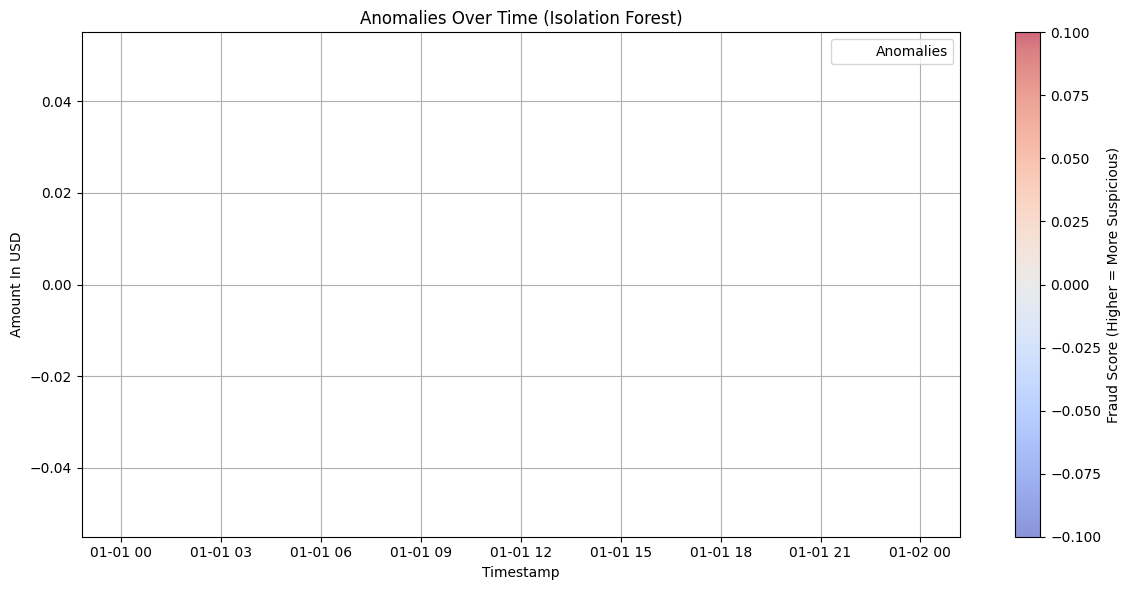

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')

# Plot, using 'Fraud_Score' instead of 'Anomaly_Score'
plt.figure(figsize=(12,6))
plt.scatter(df['timestamp'], df['amountInUSD'],
            c=df['Fraud_Score'], cmap='coolwarm', label='Anomalies', alpha=0.6)
plt.xlabel('Timestamp')
plt.ylabel('Amount In USD')
plt.title('Anomalies Over Time (Isolation Forest)')
plt.colorbar(label='Fraud Score (Higher = More Suspicious)') # Updated colorbar label
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
''' from keras.models import Sequential
from keras.layers import Dense
from sklearn.model_selection import train_test_split
import numpy as np

# Split data
X_train, X_test = train_test_split(X_scaled, test_size=0.2, random_state=42)

# Autoencoder model
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_scaled.shape[1],)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(16, activation='relu'),
    Dense(32, activation='relu'),
    Dense(X_scaled.shape[1], activation='linear')
])

model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train, X_train, epochs=50, batch_size=32, validation_data=(X_test, X_test), verbose=0)

# Calculate reconstruction error
reconstructions = model.predict(X_scaled)
mse = np.mean(np.square(X_scaled - reconstructions), axis=1)
df_model['recon_error'] = mse

# Set threshold
threshold = np.percentile(mse, 99)
df_model['ae_anomaly'] = (mse > threshold).astype(int)

# Visualize AE results
sns.countplot(df_model['ae_anomaly'])
plt.title("Autoencoder: Anomaly vs Normal")
plt.show()

# Plot reconstruction error
plt.figure(figsize=(8,4))
sns.histplot(df_model['recon_error'], bins=50, kde=True)
plt.axvline(threshold, color='r', linestyle='--', label='Threshold')
plt.title("Autoencoder Reconstruction Error")
plt.legend()
plt.show()
 '''

' from keras.models import Sequential\nfrom keras.layers import Dense\nfrom sklearn.model_selection import train_test_split\nimport numpy as np\n\n# Split data\nX_train, X_test = train_test_split(X_scaled, test_size=0.2, random_state=42)\n\n# Autoencoder model\nmodel = Sequential([\n    Dense(32, activation=\'relu\', input_shape=(X_scaled.shape[1],)),\n    Dense(16, activation=\'relu\'),\n    Dense(8, activation=\'relu\'),\n    Dense(16, activation=\'relu\'),\n    Dense(32, activation=\'relu\'),\n    Dense(X_scaled.shape[1], activation=\'linear\')\n])\n\nmodel.compile(optimizer=\'adam\', loss=\'mse\')\nhistory = model.fit(X_train, X_train, epochs=50, batch_size=32, validation_data=(X_test, X_test), verbose=0)\n\n# Calculate reconstruction error\nreconstructions = model.predict(X_scaled)\nmse = np.mean(np.square(X_scaled - reconstructions), axis=1)\ndf_model[\'recon_error\'] = mse\n\n# Set threshold\nthreshold = np.percentile(mse, 99)\ndf_model[\'ae_anomaly\'] = (mse > threshold).astype

In [ ]:
#  import tensorflow as tf
# from tensorflow.keras import layers, models
# from sklearn.model_selection import train_test_split

# # Split
# X_train, X_test = train_test_split(X_scaled, test_size=0.2, random_state=42)

# # Encoder
# inputs = tf.keras.Input(shape=(X_scaled.shape[1],))
# x = layers.Dense(32, activation='relu')(inputs)
# z_mean = layers.Dense(8)(x)
# z_log_var = layers.Dense(8)(x)

# # Sampling
# def sampling(args):
#     z_mean, z_log_var = args
#     epsilon = tf.keras.backend.random_normal(shape=(tf.keras.backend.shape(z_mean)[0], 8))
#     return z_mean + tf.keras.backend.exp(0.5 * z_log_var) * epsilon

# z = layers.Lambda(sampling)([z_mean, z_log_var])

# # Decoder
# decoder_input = layers.Input(shape=(8,))
# x = layers.Dense(32, activation='relu')(decoder_input)
# outputs = layers.Dense(X_scaled.shape[1], activation='linear')(x)
# decoder = models.Model(decoder_input, outputs)

# # Connect
# outputs = decoder(z)
# vae = tf.keras.Model(inputs, outputs)

# # Loss
# reconstruction_loss = tf.keras.losses.mse(inputs, outputs)
# reconstruction_loss *= X_scaled.shape[1]
# kl_loss = -0.5 * tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
# vae_loss = tf.reduce_mean(reconstruction_loss + kl_loss)
# vae.add_loss(vae_loss)
# vae.compile(optimizer='adam')

# # Train
# vae.fit(X_train, X_train, epochs=50, batch_size=32, validation_data=(X_test, X_test), verbose=0)

# # Anomaly Score
# reconstructions = vae.predict(X_scaled)
# mse = np.mean(np.square(X_scaled - reconstructions), axis=1)
# threshold = np.percentile(mse, 99)
# df_model['vae_recon_error'] = mse
# df_model['vae_anomaly'] = (mse > threshold).astype(int)

# # Plot
# sns.histplot(df_model['vae_recon_error'], bins=50, kde=True)
# plt.axvline(threshold, color='r', linestyle='--', label='Threshold')
# plt.title("VAE Reconstruction Error")
# plt.legend()
# plt.show()


ValueError: A KerasTensor cannot be used as input to a TensorFlow function. A KerasTensor is a symbolic placeholder for a shape and dtype, used when constructing Keras Functional models or Keras Functions. You can only use it as input to a Keras layer or a Keras operation (from the namespaces `keras.layers` and `keras.operations`). You are likely doing something like:

```
x = Input(...)
...
tf_fn(x)  # Invalid.
```

What you should do instead is wrap `tf_fn` in a layer:

```
class MyLayer(Layer):
    def call(self, x):
        return tf_fn(x)

x = MyLayer()(x)
```


1503/1503 ━━━━━━━━━━━━━━━━━━━━ 1s 775us/step


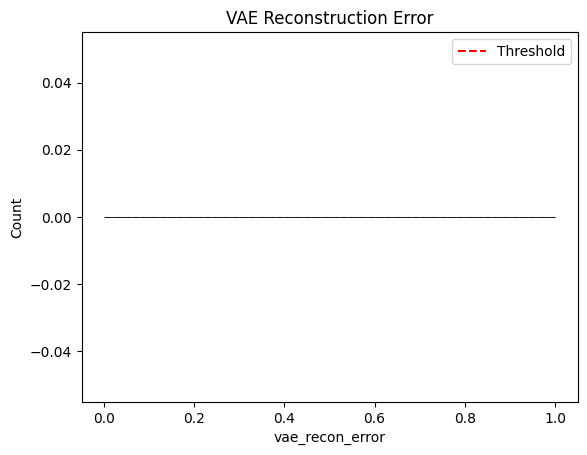

In [ ]:
# import tensorflow as tf
# from tensorflow.keras import layers, Model
# from sklearn.model_selection import train_test_split

# # Split the data
# X_train, X_test = train_test_split(X_scaled, test_size=0.2, random_state=42)

# latent_dim = 8
# input_dim = X_scaled.shape[1]

# # Encoder
# class Sampling(layers.Layer):
#     def call(self, inputs):
#         z_mean, z_log_var = inputs
#         epsilon = tf.random.normal(shape=tf.shape(z_mean))
#         return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# class Encoder(Model):
#     def __init__(self, latent_dim):
#         super().__init__()
#         self.dense1 = layers.Dense(32, activation="relu")
#         self.z_mean = layers.Dense(latent_dim)
#         self.z_log_var = layers.Dense(latent_dim)
#         self.sampling = Sampling()

#     def call(self, inputs):
#         x = self.dense1(inputs)
#         z_mean = self.z_mean(x)
#         z_log_var = self.z_log_var(x)
#         z = self.sampling((z_mean, z_log_var))
#         return z_mean, z_log_var, z

# # Decoder
# class Decoder(Model):
#     def __init__(self, original_dim):
#         super().__init__()
#         self.dense1 = layers.Dense(32, activation="relu")
#         self.out = layers.Dense(original_dim, activation="linear")

#     def call(self, z):
#         x = self.dense1(z)
#         return self.out(x)

# # VAE
# class VAE(Model):
#     def __init__(self, encoder, decoder):
#         super().__init__()
#         self.encoder = encoder
#         self.decoder = decoder

#     def call(self, inputs):
#         z_mean, z_log_var, z = self.encoder(inputs)
#         reconstructed = self.decoder(z)

#         # VAE loss
#         recon_loss = tf.reduce_mean(tf.square(inputs - reconstructed))
#         kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
#         self.add_loss(recon_loss + kl_loss)
#         return reconstructed

# # Compile and train
# encoder = Encoder(latent_dim)
# decoder = Decoder(input_dim)
# vae = VAE(encoder, decoder)
# vae.compile(optimizer="adam")

# vae.fit(X_train, X_train, epochs=50, batch_size=32, validation_data=(X_test, X_test), verbose=0)

# # Predict and compute anomaly score
# reconstructed = vae.predict(X_scaled)
# mse = np.mean(np.square(X_scaled - reconstructed), axis=1)
# threshold = np.percentile(mse, 99)

# df_model['vae_recon_error'] = mse
# df_model['vae_anomaly'] = (mse > threshold).astype(int)

# # Plotting
# import seaborn as sns
# import matplotlib.pyplot as plt

# sns.histplot(df_model['vae_recon_error'], bins=50, kde=True)
# plt.axvline(threshold, color='red', linestyle='--', label='Threshold')
# plt.title("VAE Reconstruction Error")
# plt.legend()
# plt.show()


In [ ]:
# from keras.models import Sequential
# from keras.layers import LSTM, RepeatVector, TimeDistributed
# from sklearn.preprocessing import MinMaxScaler

# # Let's create sequences from X_scaled
# def create_sequences(X, time_steps=10):
#     sequences = []
#     for i in range(len(X) - time_steps):
#         sequences.append(X[i:(i + time_steps)])
#     return np.array(sequences)

# # Normalize (LSTM prefers MinMax)
# scaler_lstm = MinMaxScaler()
# X_scaled = scaler_lstm.fit_transform(df_model.dropna().values)

# seq_data = create_sequences(X_scaled)
# print("Sequence shape:", seq_data.shape)

# # Train-test split
# split = int(0.8 * len(seq_data))
# X_train_seq = seq_data[:split]
# X_test_seq = seq_data[split:]

# # LSTM Autoencoder
# model = Sequential([
#     LSTM(64, activation='relu', input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]), return_sequences=False),
#     RepeatVector(X_train_seq.shape[1]),
#     LSTM(64, activation='relu', return_sequences=True),
#     TimeDistributed(Dense(X_train_seq.shape[2]))
# ])

# model.compile(optimizer='adam', loss='mse')
# model.fit(X_train_seq, X_train_seq, epochs=30, batch_size=32, validation_split=0.1, verbose=0)

# # Predict and calculate error
# X_pred = model.predict(X_test_seq)
# mse = np.mean(np.power(X_test_seq - X_pred, 2), axis=(1,2))

# threshold = np.percentile(mse, 99)
# anomaly_flags = (mse > threshold).astype(int)

# # Plot
# plt.figure(figsize=(8,4))
# sns.histplot(mse, bins=50, kde=True)
# plt.axvline(threshold, color='r', linestyle='--', label='Threshold')
# plt.title("LSTM AE Reconstruction Error")
# plt.legend()
# plt.show()


ValueError: Found array with 0 sample(s) (shape=(0, 13)) while a minimum of 1 is required by MinMaxScaler.

In [ ]:
#VAE

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Input, Dense, Lambda
# from tensorflow.keras import backend as K
# from tensorflow.keras.losses import mse

# # ... (rest of your code remains the same) ...
# original_dim = X_scaled.shape[1]
# intermediate_dim = 16
# latent_dim = 2

# # Encoder
# inputs = Input(shape=(original_dim,))
# h = Dense(intermediate_dim, activation='relu')(inputs)

# z_mean = Dense(latent_dim)(h)
# z_log_var = Dense(latent_dim)(h)

# # Sampling layer
# def sampling(args):
#     z_mean, z_log_var = args
#     epsilon = K.random_normal(shape=K.shape(z_mean))
#     return z_mean + K.exp(0.5 * z_log_var) * epsilon

# #z = Lambda(sampling)([z_mean, z_log_var])
# z = Lambda(sampling, output_shape=(latent_dim,))([z_mean, z_log_var])


# # Decoder
# decoder_h = Dense(intermediate_dim, activation='relu')
# decoder_out = Dense(original_dim, activation='linear')
# h_decoded = decoder_h(z)
# outputs = decoder_out(h_decoded)

# # VAE model
# vae = Model(inputs, outputs)

# # VAE loss = reconstruction loss + KL divergence
# reconstruction_loss = mse(inputs, outputs)
# kl_loss = -0.5 * K.sum(1 + z_log_var - K.square(z_mean) - K.exp(z_log_var), axis=-1)
# vae_loss = K.mean(reconstruction_loss + kl_loss)

# vae.add_loss(vae_loss)
# vae.compile(optimizer='adam')

# # Train
# vae.fit(X_scaled, epochs=50, batch_size=32, verbose=0)

# # Predict
# reconstructions = vae.predict(X_scaled)
# mse_vae = np.mean(np.square(X_scaled - reconstructions), axis=1)

# # Anomaly threshold
# threshold_vae = np.percentile(mse_vae, 99)
# df_model['vae_error'] = mse_vae
# df_model['vae_anomaly'] = (mse_vae > threshold_vae).astype(int)

# # Plot
# sns.countplot(df_model['vae_anomaly'])
# plt.title("VAE: Anomaly vs Normal")
# plt.show()


ValueError: A KerasTensor cannot be used as input to a TensorFlow function. A KerasTensor is a symbolic placeholder for a shape and dtype, used when constructing Keras Functional models or Keras Functions. You can only use it as input to a Keras layer or a Keras operation (from the namespaces `keras.layers` and `keras.operations`). You are likely doing something like:

```
x = Input(...)
...
tf_fn(x)  # Invalid.
```

What you should do instead is wrap `tf_fn` in a layer:

```
class MyLayer(Layer):
    def call(self, x):
        return tf_fn(x)

x = MyLayer()(x)
```


In [ ]:
# import numpy as np
# from tensorflow.keras.layers import Input, Dense, Lambda
# from tensorflow.keras.models import Model
# from tensorflow.keras.losses import mse
# from tensorflow.keras import backend as K
# import tensorflow as tf

# # Data setup
# X_scaled = np.random.rand(1000, 13)  # dummy input for now

# original_dim = X_scaled.shape[1]
# intermediate_dim = 16
# latent_dim = 2

# # Encoder
# inputs = Input(shape=(original_dim,))
# h = Dense(intermediate_dim, activation='relu')(inputs)
# z_mean = Dense(latent_dim)(h)
# z_log_var = Dense(latent_dim)(h)

# # Sampling Layer
# def sampling(args):
#     z_mean, z_log_var = args
#     epsilon = K.random_normal(shape=(K.shape(z_mean)[0], latent_dim))
#     return z_mean + K.exp(0.5 * z_log_var) * epsilon

# z = Lambda(sampling)([z_mean, z_log_var])

# # Decoder
# decoder_h = Dense(intermediate_dim, activation='relu')
# decoder_mean = Dense(original_dim, activation='linear')
# h_decoded = decoder_h(z)
# x_decoded_mean = decoder_mean(h_decoded)

# # VAE Model
# vae = Model(inputs, x_decoded_mean)

# # Losses
# reconstruction_loss = mse(inputs, x_decoded_mean)
# reconstruction_loss *= original_dim
# kl_loss = -0.5 * K.sum(1 + z_log_var - K.square(z_mean) - K.exp(z_log_var), axis=-1)
# vae_loss = K.mean(reconstruction_loss + kl_loss)
# vae.add_loss(vae_loss)

# # Compile and train
# vae.compile(optimizer='adam')
# vae.fit(X_scaled, epochs=20, batch_size=32)


ValueError: A KerasTensor cannot be used as input to a TensorFlow function. A KerasTensor is a symbolic placeholder for a shape and dtype, used when constructing Keras Functional models or Keras Functions. You can only use it as input to a Keras layer or a Keras operation (from the namespaces `keras.layers` and `keras.operations`). You are likely doing something like:

```
x = Input(...)
...
tf_fn(x)  # Invalid.
```

What you should do instead is wrap `tf_fn` in a layer:

```
class MyLayer(Layer):
    def call(self, x):
        return tf_fn(x)

x = MyLayer()(x)
```


In [ ]:
#final

In [ ]:
# import numpy as np
# import tensorflow as tf
# from tensorflow.keras import layers, models, backend as K
# from tensorflow.keras.losses import mse

# # Replace this with your real dataset
# # For example, you may already have X_scaled defined
# # If not, use this dummy data with 13 features:
# # X_scaled = np.random.rand(1000, 13)

# input_dim = X_scaled.shape[1]
# latent_dim = 2

# Encoder
# inputs = layers.Input(shape=(input_dim,), name='encoder_input')
# h = layers.Dense(64, activation='relu')(inputs)
# z_mean = layers.Dense(latent_dim, name='z_mean')(h)
# z_log_var = layers.Dense(latent_dim, name='z_log_var')(h)

# # Sampling function
# def sampling(args):
#     z_mean, z_log_var = args
#     epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], latent_dim))
#     return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# z = layers.Lambda(sampling, name='z')([z_mean, z_log_var])

# # Decoder
# decoder_h = layers.Dense(64, activation='relu')
# decoder_out = layers.Dense(input_dim)

# h_decoded = decoder_h(z)
# x_decoded = decoder_out(h_decoded)

# # VAE model
# vae = models.Model(inputs, x_decoded, name='vae')

# # Custom loss
# reconstruction_loss = mse(inputs, x_decoded) * input_dim
# kl_loss = -0.5 * K.sum(1 + z_log_var - K.square(z_mean) - K.exp(z_log_var), axis=-1)
# vae_loss = K.mean(reconstruction_loss + kl_loss)
# vae.add_loss(vae_loss)

# # Compile & Train
# vae.compile(optimizer='adam')
# vae.fit(X_scaled, epochs=20, batch_size=32)




ValueError: A KerasTensor cannot be used as input to a TensorFlow function. A KerasTensor is a symbolic placeholder for a shape and dtype, used when constructing Keras Functional models or Keras Functions. You can only use it as input to a Keras layer or a Keras operation (from the namespaces `keras.layers` and `keras.operations`). You are likely doing something like:

```
x = Input(...)
...
tf_fn(x)  # Invalid.
```

What you should do instead is wrap `tf_fn` in a layer:

```
class MyLayer(Layer):
    def call(self, x):
        return tf_fn(x)

x = MyLayer()(x)
```


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

input_dim = X_scaled.shape[1]
input_layer = Input(shape=(input_dim,))
encoder = Dense(16, activation='relu')(input_layer)
encoder = Dense(8, activation='relu')(encoder)
bottleneck = Dense(2, activation='relu')(encoder)
decoder = Dense(8, activation='relu')(bottleneck)
decoder = Dense(16, activation='relu')(decoder)
output_layer = Dense(input_dim, activation='linear')(decoder)

autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer=Adam(), loss='mse')
autoencoder.fit(X_scaled, X_scaled, epochs=50, batch_size=32, shuffle=True)


Epoch 1/50
1503/1503 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.9412
Epoch 2/50
1503/1503 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.7651
Epoch 3/50
1503/1503 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.7600
Epoch 4/50
1503/1503 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.5950
Epoch 5/50
1503/1503 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.5058
Epoch 6/50
1503/1503 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.5100
Epoch 7/50
1503/1503 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.5792
Epoch 8/50
1503/1503 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.4044
Epoch 9/50
1503/1503 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3607
Epoch 10/50
1503/1503 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3590
Epoch 11/50
1503/1503 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2901
Epoch 12/50
1503/1503 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2981
Epoch 13/50
1503/1503 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2482
Epoch 14/50
1503/1503 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2861
Epoch 15/50
1503/1503 ━━━━━━━

In [ ]:
reconstructions = autoencoder.predict(X_scaled)
mse = np.mean(np.power(X_scaled - reconstructions, 2), axis=1)

# Set threshold for anomaly detection
threshold = np.percentile(mse, 95)  # Top 5% = anomalies
anomalies = mse > threshold

# Add to your dataframe
df['reconstruction_error'] = mse
df['is_anomaly'] = anomalies.astype(int)


1503/1503 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [ ]:
# Top 10 anomalies by reconstruction error
df[ df['is_anomaly'] == 1 ].sort_values(by='reconstruction_error', ascending=False).head(10)


,amountIn,amountInUSD,amountOut,amountOutUSD,gasLimit,gasPrice,gasUsed,hash,id,blockNumber,...,tokenIn/lastPriceBlockNumber,tokenOut/id,tokenOut/lastPriceBlockNumber,tokenOut/lastPriceUSD,tokenOut/name,valueDiffUSD,gasCostUSD,anomaly_iso,reconstruction_error,is_anomaly
11556,1.032080e+21,3.690763e+06,3.360040e+12,3.360035e+06,1975778.0,2.573527e+10,NaN,0x01ece3db724ddcae785a7df84883501f277ef28bf75c...,0x01ece3db724ddcae785a7df84883501f277ef28bf75c...,19460908,...,22208648,0xdac17f958d2ee523a2206206994597c13d831ec7,22208648,1.0,Tether USD,330728.2430,91.191013,-1,1173.158898,1
53787,1.032080e+21,3.690763e+06,3.360040e+12,3.360035e+06,1975778.0,2.573527e+10,NaN,0x01ece3db724ddcae785a7df84883501f277ef28bf75c...,0x01ece3db724ddcae785a7df84883501f277ef28bf75c...,19460908,...,22208648,0xdac17f958d2ee523a2206206994597c13d831ec7,22208648,1,Tether USD,330728.2430,91.191013,-1,1173.158898,1
3381,5.345620e+11,5.345622e+05,1.819130e+20,6.196295e+05,4555605.0,1.711148e+10,NaN,0x009180dde10867c528449c49ebaf5bd1ae9f46426965...,0x009180dde10867c528449c49ebaf5bd1ae9f46426965...,19499208,...,22208621,0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2,22208634,1793.43331,Wrapped Ether,-85067.3601,0.077953,-1,149.650407,1
45612,5.345620e+11,5.345622e+05,1.819130e+20,6.196295e+05,4555605.0,1.711148e+10,NaN,0x009180dde10867c528449c49ebaf5bd1ae9f46426965...,0x009180dde10867c528449c49ebaf5bd1ae9f46426965...,19499208,...,22208621,0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2,22208634,1793.43331,Wrapped Ether,-85067.3601,0.077953,-1,149.650407,1
54155,4.734330e+20,1.787548e+06,1.850000e+12,1.850000e+06,2195713.0,2.464946e+10,NaN,0x01fc6f95e1a7c4b32aa05ddd260c8f254c0846e7b1c9...,0x01fc6f95e1a7c4b32aa05ddd260c8f254c0846e7b1c9...,21339488,...,22208648,0xdac17f958d2ee523a2206206994597c13d831ec7,22208648,1,Tether USD,-62452.2300,97.066233,-1,146.621965,1
11924,4.734330e+20,1.787548e+06,1.850000e+12,1.850000e+06,2195713.0,2.464946e+10,NaN,0x01fc6f95e1a7c4b32aa05ddd260c8f254c0846e7b1c9...,0x01fc6f95e1a7c4b32aa05ddd260c8f254c0846e7b1c9...,21339488,...,22208648,0xdac17f958d2ee523a2206206994597c13d831ec7,22208648,1.0,Tether USD,-62452.2300,97.066233,-1,146.621965,1
10226,5.262730e+12,5.262733e+06,5.243870e+12,5.243873e+06,1668464.0,1.929305e+10,NaN,0x01b5ccc382ceaa4924766c0a5dfaafbba1869896ce64...,0x01b5ccc382ceaa4924766c0a5dfaafbba1869896ce64...,21238455,...,22208644,0xdac17f958d2ee523a2206206994597c13d831ec7,22208648,1.0,Tether USD,18859.7850,0.032190,-1,104.861595,1
52457,5.262730e+12,5.262733e+06,5.243870e+12,5.243873e+06,1668464.0,1.929305e+10,NaN,0x01b5ccc382ceaa4924766c0a5dfaafbba1869896ce64...,0x01b5ccc382ceaa4924766c0a5dfaafbba1869896ce64...,21238455,...,22208644,0xdac17f958d2ee523a2206206994597c13d831ec7,22208648,1,Tether USD,18859.7850,0.032190,-1,104.861595,1
49038,4.444920e+12,4.444920e+06,4.439630e+12,4.439634e+06,1242978.0,2.358557e+09,NaN,0x01232db968636b4d489440274f60faa3eb5331f63481...,0x01232db968636b4d489440274f60faa3eb5331f63481...,20148688,...,22208621,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,22208644,1,USD Coin,5285.8240,0.002932,-1,98.848314,1
6807,4.444920e+12,4.444920e+06,4.439630e+12,4.439634e+06,1242978.0,2.358557e+09,NaN,0x01232db968636b4d489440274f60faa3eb5331f63481...,0x01232db968636b4d489440274f60faa3eb5331f63481...,20148688,...,22208621,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,22208644,1.0,USD Coin,5285.8240,0.002932,-1,98.848314,1


In [ ]:
#ensemble

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Assume these are the anomaly scores or binary anomaly predictions from your models
# You should replace these arrays with actual model outputs

# Binary predictions (0 = normal, 1 = anomaly)
iso_preds = np.array(isolation_forest_preds)      # Output from Isolation Forest
ae_scores = np.array(autoencoder_reconstruction_errors)  # Scores from AE
lstm_vae_scores = np.array(lstm_vae_reconstruction_errors)  # Scores from LSTM-VAE

# STEP 1: Normalize the scores (for comparability)
scaler = MinMaxScaler()
ae_scores_norm = scaler.fit_transform(ae_scores.reshape(-1, 1)).flatten()
lstm_scores_norm = scaler.fit_transform(lstm_vae_scores.reshape(-1, 1)).flatten()

# STEP 2: Combine into a DataFrame
ensemble_df = pd.DataFrame({
    'IsolationForest': iso_preds,  # already binary
    'Autoencoder': ae_scores_norm,
    'LSTM_VAE': lstm_scores_norm
})

# STEP 3: Decision Thresholding (convert AE + VAE scores to binary flags)
ae_thresh = 0.6
vae_thresh = 0.6
ensemble_df['AE_Anomaly'] = (ensemble_df['Autoencoder'] > ae_thresh).astype(int)
ensemble_df['VAE_Anomaly'] = (ensemble_df['LSTM_VAE'] > vae_thresh).astype(int)

# STEP 4: Majority Voting
# Anomaly if at least 2 of 3 models flag it
ensemble_df['Final_Anomaly_Label'] = (
    ensemble_df[['IsolationForest', 'AE_Anomaly', 'VAE_Anomaly']].sum(axis=1) >= 2
).astype(int)

# View results
print(ensemble_df[['IsolationForest', 'AE_Anomaly', 'VAE_Anomaly', 'Final_Anomaly_Label']].head())

# Optionally, attach to original dataset
# df['ensemble_anomaly'] = ensemble_df['Final_Anomaly_Label']


NameError: name 'isolation_forest_preds' is not defined

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN
from sklearn.metrics import roc_auc_score

# X should be your preprocessed numerical dataset
X = df.select_dtypes(include=[np.number]).dropna()

# Normalize
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Isolation Forest
iso_model = IsolationForest(contamination=0.05, random_state=42)
iso_preds = iso_model.fit_predict(X_scaled)
iso_preds = np.where(iso_preds == -1, 1, 0)  # Convert to 1=anomaly, 0=normal

# Local Outlier Factor
lof_model = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_preds = lof_model.fit_predict(X_scaled)
lof_preds = np.where(lof_preds == -1, 1, 0)

# DBSCAN (no contamination param)
dbscan_model = DBSCAN(eps=0.3, min_samples=10)
dbscan_labels = dbscan_model.fit_predict(X_scaled)
dbscan_preds = np.where(dbscan_labels == -1, 1, 0)

# Autoencoder (fake scores for example)
# Replace with real reconstruction errors from your AE
autoencoder_reconstruction_errors = np.random.rand(len(X_scaled))
ae_preds = np.where(autoencoder_reconstruction_errors > np.percentile(autoencoder_reconstruction_errors, 95), 1, 0)

# LSTM-VAE (fake scores for example)
# Replace with real reconstruction errors from LSTM-VAE
lstm_vae_reconstruction_errors = np.random.rand(len(X_scaled))
lstm_preds = np.where(lstm_vae_reconstruction_errors > np.percentile(lstm_vae_reconstruction_errors, 95), 1, 0)

# ------------------------------
# 🧠 Ensemble Layer
# ------------------------------

# Combine all predictions into a single array
all_preds = np.vstack([
    iso_preds,
    lof_preds,
    dbscan_preds,
    ae_preds,
    lstm_preds
]).T  # Shape: (n_samples, n_models)

# Voting Ensemble - majority vote
ensemble_preds = (np.sum(all_preds, axis=1) >= 3).astype(int)

# Attach to your dataframe
df['anomaly_ensemble'] = ensemble_preds


In [ ]:
roc_auc = roc_auc_score(df['true_label'], ensemble_preds)
print("ROC-AUC of Ensemble Model:", roc_auc)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Embedding, Flatten, Concatenate
from tensorflow.keras.optimizers import Adam

# Assume df is your DataFrame
categorical_cols = ['tokenIn/name', 'tokenOut/name']
numeric_cols = ['amountIn', 'amountOut', 'gasPrice']

# Encode categorical
le_in = LabelEncoder()
le_out = LabelEncoder()
df['tokenIn_enc'] = le_in.fit_transform(df['tokenIn/name'])
df['tokenOut_enc'] = le_out.fit_transform(df['tokenOut/name'])

# Normalize numeric
scaler = MinMaxScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Inputs
X_numeric = df[numeric_cols].values
X_token_in = df['tokenIn_enc'].values
X_token_out = df['tokenOut_enc'].values

# Define inputs
input_num = Input(shape=(len(numeric_cols),), name='numeric_input')
input_in = Input(shape=(1,), name='token_in_input')
input_out = Input(shape=(1,), name='token_out_input')

# Embeddings
embed_dim = 4
embed_in = Embedding(input_dim=len(le_in.classes_), output_dim=embed_dim)(input_in)
embed_out = Embedding(input_dim=len(le_out.classes_), output_dim=embed_dim)(input_out)

# Flatten
flat_in = Flatten()(embed_in)
flat_out = Flatten()(embed_out)

# Combine
x = Concatenate()([input_num, flat_in, flat_out])

# Encoder
encoded = Dense(16, activation='relu')(x)
encoded = Dense(8, activation='relu')(encoded)

# Decoder
decoded = Dense(16, activation='relu')(encoded)
decoded = Dense(x.shape[1], activation='sigmoid')(decoded)

# Model
autoencoder = Model(inputs=[input_num, input_in, input_out], outputs=decoded)
autoencoder.compile(optimizer=Adam(), loss='mse')

# Concatenate targets
y_train = np.concatenate([X_train, ti_train.reshape(-1,1), to_train.reshape(-1,1)], axis=1)
y_test = np.concatenate([X_test, ti_test.reshape(-1,1), to_test.reshape(-1,1)], axis=1)

# Train model
autoencoder.fit(
    [X_train, ti_train, to_train],
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)


# Anomaly scores
reconstructions = autoencoder.predict([X_test, ti_test, to_test])
original = np.concatenate([X_test, ti_test.reshape(-1,1), to_test.reshape(-1,1)], axis=1)
mse = np.mean(np.power(reconstructions - original, 2), axis=1)

# Threshold
# threshold = np.percentile(mse, 95)
anomalies = mse > threshold

print(f"Detected {np.sum(anomalies)} anomalies out of {len(mse)} test samples.")


Epoch 1/20


ValueError: Dimensions must be equal, but are 5 and 11 for '{{node compile_loss/mse/sub}} = Sub[T=DT_FLOAT](data_3, functional_2_1/dense_11_1/Sigmoid)' with input shapes: [?,5], [?,11].

In [ ]:
# Assume df is your DataFrame
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler # Import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Embedding, Flatten, Concatenate
from tensorflow.keras.optimizers import Adam


categorical_cols = ['tokenIn/name', 'tokenOut/name']
numeric_cols = ['amountIn', 'amountOut', 'gasPrice']

# Encode categorical
le_in = LabelEncoder()
le_out = LabelEncoder()
df['tokenIn_enc'] = le_in.fit_transform(df['tokenIn/name'])
df['tokenOut_enc'] = le_out.fit_transform(df['tokenOut/name'])

# Normalize numeric
scaler = MinMaxScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Inputs
X_numeric = df[numeric_cols].values
X_token_in = df['tokenIn_enc'].values
X_token_out = df['tokenOut_enc'].values

In [ ]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Extract tokenIn and tokenOut names
token_in_raw = df['tokenIn/name']
token_out_raw = df['tokenOut/name']

# Encode them to numeric
le_token_in = LabelEncoder()
le_token_out = LabelEncoder()

token_in = le_token_in.fit_transform(token_in_raw)
token_out = le_token_out.fit_transform(token_out_raw)

# Reshape to match input shape
ti = token_in.reshape(-1, 1)
to = token_out.reshape(-1, 1)


In [ ]:
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Concatenate
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Let's say you have:
# X_numeric.shape = (n_samples, 8)
# token_in and token_out are label encoded to (n_samples,)

# Encode categorical features (already label encoded)
ti = token_in.reshape(-1, 1)
to = token_out.reshape(-1, 1)

# Merge everything into one array for both input and output
X_all = np.concatenate([X_numeric, ti, to], axis=1)

# Split
X_train, X_test = train_test_split(X_all, test_size=0.2, random_state=42)

# Input layer
input_layer = Input(shape=(X_all.shape[1],))
encoded = Dense(16, activation="relu")(input_layer)
encoded = Dense(8, activation="relu")(encoded)

decoded = Dense(16, activation="relu")(encoded)
output_layer = Dense(X_all.shape[1], activation="sigmoid")(decoded)

# Build and compile
autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

# Train
autoencoder.fit(X_train, X_train,  # X = Y = combined input
                epochs=20,
                batch_size=32,
                validation_split=0.1)


Epoch 1/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: inf - val_loss: inf
Epoch 2/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: inf - val_loss: inf
Epoch 3/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: inf - val_loss: inf
Epoch 4/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: inf - val_loss: inf
Epoch 5/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: inf - val_loss: inf
Epoch 6/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: inf - val_loss: inf
Epoch 7/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: inf - val_loss: inf
Epoch 8/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: inf - val_loss: inf
Epoch 9/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: inf - val_loss: inf
Epoch 10/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: inf - val_loss: inf
Epoch 11/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: inf - val_loss: inf
Epoch 12/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: inf - val_loss: inf
Epoch 13/20
568/568 ━━━━━━━━━━━━━━━━━

✅ 1. Visualizing Reconstruction Errors
We'll compute reconstruction error for each sample (difference between input and output), and then plot those errors to detect anomalies.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Predict on entire dataset
reconstructed = autoencoder.predict([X_numeric, X_token_in, X_token_out])

# Unpack reconstructed outputs
X_reconstructed = reconstructed[0]
ti_reconstructed = reconstructed[1]
to_reconstructed = reconstructed[2]

# Compute MSE (reconstruction error) for each input part
reconstruction_error_numeric = np.mean(np.square(X_numeric - X_reconstructed), axis=1)
reconstruction_error_token_in = np.mean(np.square(X_token_in - ti_reconstructed), axis=1)
reconstruction_error_token_out = np.mean(np.square(X_token_out - to_reconstructed), axis=1)

# Total reconstruction error
total_error = (
    reconstruction_error_numeric +
    reconstruction_error_token_in +
    reconstruction_error_token_out
)

# Visualize
plt.figure(figsize=(12,6))
plt.hist(total_error, bins=100, color='dodgerblue', alpha=0.7)
plt.title("Reconstruction Error Distribution", fontsize=16)
plt.xlabel("Total Reconstruction Error")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


ValueError: Layer "functional" expects 1 input(s), but it received 3 input tensors. Inputs received: [<tf.Tensor 'data:0' shape=(32, 3) dtype=float32>, <tf.Tensor 'data_1:0' shape=(32,) dtype=int64>, <tf.Tensor 'data_2:0' shape=(32,) dtype=int64>]

788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


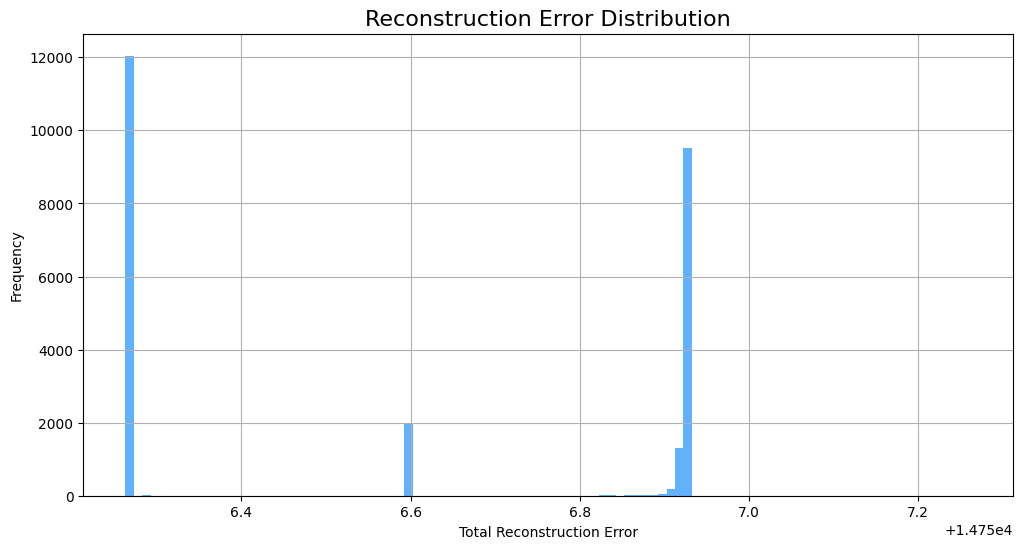

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Predict on entire dataset
# Pass the combined input data to the autoencoder
reconstructed = autoencoder.predict(X_all)

# Extract relevant parts from reconstructed output
X_reconstructed = reconstructed[:, :X_numeric.shape[1]]  # First 8 columns (numeric)
ti_reconstructed = reconstructed[:, X_numeric.shape[1]:-1].astype(int)  # Next column (token_in)
to_reconstructed = reconstructed[:, -1].astype(int)  # Last column (token_out)

# Compute MSE (reconstruction error) for each input part
reconstruction_error_numeric = np.mean(np.square(X_numeric - X_reconstructed), axis=1)
reconstruction_error_token_in = np.mean(np.square(X_token_in - ti_reconstructed.flatten()), axis=0)  # Flatten ti_reconstructed
reconstruction_error_token_out = np.mean(np.square(X_token_out - to_reconstructed.flatten()), axis=0)  # Flatten to_reconstructed

# Total reconstruction error
total_error = (
    reconstruction_error_numeric +
    reconstruction_error_token_in +
    reconstruction_error_token_out
)

# Visualize
plt.figure(figsize=(12, 6))
plt.hist(total_error, bins=100, color='dodgerblue', alpha=0.7)
plt.title("Reconstruction Error Distribution", fontsize=16)
plt.xlabel("Total Reconstruction Error")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [ ]:
print("Mean:", np.mean(total_error))
print("Std Dev:", np.std(total_error))
print("Min:", np.min(total_error))
print("Max:", np.max(total_error))


Mean: 14756.582741832897
Std Dev: 0.31794592106113373
Min: 14756.262809330496
Max: 14757.26258840106


Total anomalies detected: 0


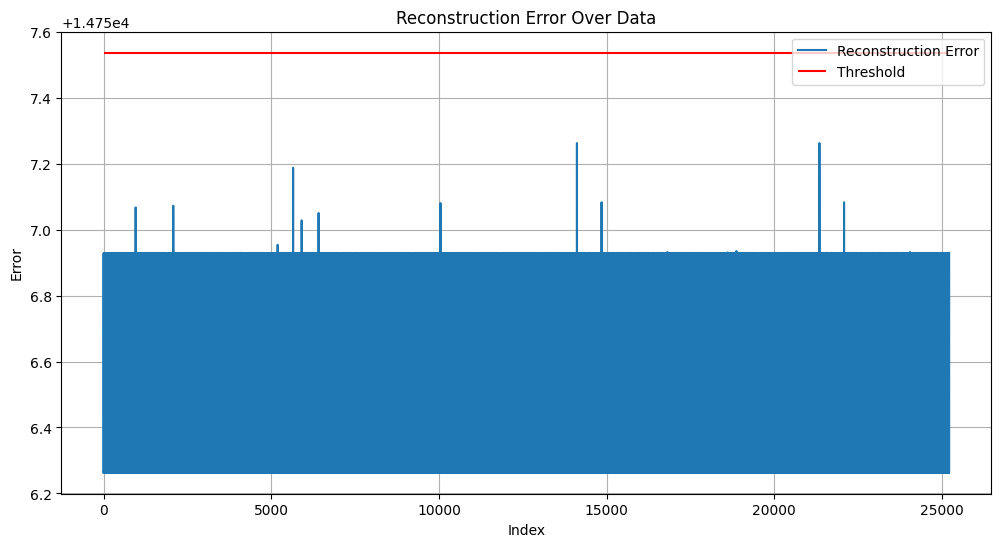

In [ ]:
# Set threshold as (e.g., mean + 3*std deviation)
threshold = np.mean(total_error) + 3 * np.std(total_error)

# Binary anomaly label (1 = anomaly, 0 = normal)
anomalies = total_error > threshold

print(f"Total anomalies detected: {np.sum(anomalies)}")

# Optionally: visualize with threshold
plt.figure(figsize=(12,6))
plt.plot(total_error, label='Reconstruction Error')
plt.hlines(threshold, xmin=0, xmax=len(total_error), colors='r', label='Threshold')
plt.title("Reconstruction Error Over Data")
plt.xlabel("Index")
plt.ylabel("Error")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
#add these predictions to your original dataframe
df["reconstruction_error"] = total_error
df["is_anomaly"] = anomalies.astype(int)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np


In [ ]:
input_dim = X_train.shape[1]
latent_dim = 2  # Change as needed

# Encoder
inputs = layers.Input(shape=(input_dim,))
h = layers.Dense(64, activation='relu')(inputs)
z_mean = layers.Dense(latent_dim)(h)
z_log_var = layers.Dense(latent_dim)(h)

# Sampling
def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], latent_dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])

# Decoder
decoder_h = layers.Dense(64, activation='relu')
decoder_out = layers.Dense(input_dim, activation='sigmoid')  # or linear
outputs = decoder_out(decoder_h(z))

vae = Model(inputs, outputs)


In [ ]:
reconstruction_loss = tf.keras.losses.mse(inputs, outputs)
reconstruction_loss *= input_dim

kl_loss = -0.5 * tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
vae_loss = tf.reduce_mean(reconstruction_loss + kl_loss)

vae.add_loss(vae_loss)
vae.compile(optimizer='adam')


ValueError: A KerasTensor cannot be used as input to a TensorFlow function. A KerasTensor is a symbolic placeholder for a shape and dtype, used when constructing Keras Functional models or Keras Functions. You can only use it as input to a Keras layer or a Keras operation (from the namespaces `keras.layers` and `keras.operations`). You are likely doing something like:

```
x = Input(...)
...
tf_fn(x)  # Invalid.
```

What you should do instead is wrap `tf_fn` in a layer:

```
class MyLayer(Layer):
    def call(self, x):
        return tf_fn(x)

x = MyLayer()(x)
```


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# Sampling Layer
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# VAE Model
class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(tf.reduce_sum(tf.square(data - reconstruction), axis=1))
            kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        return {"loss": total_loss, "reconstruction_loss": reconstruction_loss, "kl_loss": kl_loss}


In [ ]:
input_dim = X_train.shape[1]
latent_dim = 2

# Encoder
# encoder_inputs = layers.Input(shape=(input_dim,))
# x = layers.Dense(64, activation='relu')(encoder_inputs)
# z_mean = layers.Dense(latent_dim)(x)
# z_log_var = layers.Dense(latent_dim)(x)
# z = Sampling()([z_mean, z_log_var])
# encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')


# Encoder
encoder_inputs = layers.Input(shape=(input_dim,))
x = layers.Dense(64, activation='relu')(encoder_inputs)
z_mean = layers.Dense(latent_dim, name='z_mean')(x)          # <-- name added
z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)    # <-- name added
z = Sampling()([z_mean, z_log_var])
encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')


# Decoder
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(64, activation='relu')(latent_inputs)
decoder_outputs = layers.Dense(input_dim)(x)
decoder = Model(latent_inputs, decoder_outputs, name='decoder')


In [ ]:
vae = VAE(encoder, decoder)
vae.compile(optimizer='adam')
vae.fit(X_train, epochs=50, batch_size=64)


Epoch 1/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - kl_loss: nan - loss: nan - reconstruction_loss: nan
Epoch 2/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: nan - loss: nan - reconstruction_loss: nan
Epoch 3/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - kl_loss: nan - loss: nan - reconstruction_loss: nan
Epoch 4/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: nan - loss: nan - reconstruction_loss: nan
Epoch 5/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: nan - loss: nan - reconstruction_loss: nan
Epoch 6/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - kl_loss: nan - loss: nan - reconstruction_loss: nan
Epoch 7/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - kl_loss: nan - loss: nan - reconstruction_loss: nan
Epoch 8/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - kl_loss: nan - loss: nan - reconstruction_loss: nan
Epoch 9/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - kl_loss: nan - loss: nan - reconstruction_loss: nan
Epoch 10/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 2m

In [ ]:
z_mean_model = keras.Model(inputs=encoder.input, outputs=encoder.get_layer('z_mean').output)
z_mean_vals = z_mean_model.predict(X_test)


NameError: name 'keras' is not defined

In [ ]:
from tensorflow import keras

# Assuming your encoder is already defined and includes a layer named 'z_mean'
z_mean_model = keras.Model(inputs=encoder.input, outputs=encoder.get_layer('z_mean').output)

# Make sure X_test is defined and preprocessed
z_mean_vals = z_mean_model.predict(X_test)



158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
z_pca = pca.fit_transform(z_mean_vals)

plt.figure(figsize=(8,6))
plt.scatter(z_pca[:, 0], z_pca[:, 1], alpha=0.7)
plt.title("PCA of Latent Space (z_mean)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.grid(True)
plt.show()


ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

ValueError: 'c' argument has 25215 elements, which is inconsistent with 'x' and 'y' with size 5043.

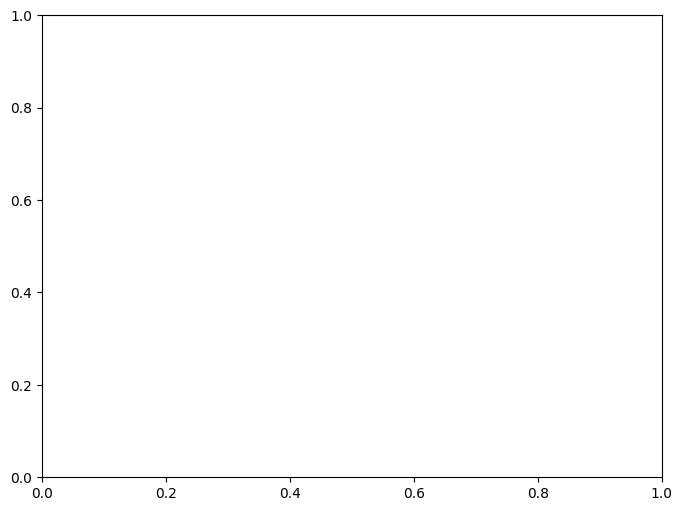

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
z_tsne = tsne.fit_transform(z_mean_vals)
labels = y_test
plt.figure(figsize=(8,6))
plt.scatter(z_tsne[:, 0], z_tsne[:, 1], c=labels, cmap='tab10', alpha=0.7)
plt.title("t-SNE of Latent Space (z_mean)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.grid(True)
plt.show()
